# VAR: 다중 시계열 예측

SARIMAX는 외생 변수가 시계열에 미치는 영향. 관계가 **단방향**이므로 외생 변수가 대상에만 영향을 미친다고 가정.  

하지만 두 시계열이 양방향 관계를 가질수도 있음. 즉, 시계열 t1이 시계열 t2의 예측 변수이고, 시계열 t2가 시계열 t1의 예측 변수가 될 수도 있음. 이런 경우 이 양방향 관계를 고려해 두 시계열에 대한 예측을 동시에 출력할 수 있는 모델이 있다면 유용.  

VAR: Vector Autoregression (벡터자기회귀)
- 시간에 따라 변화하는 여러 시계열 간의 관계를 포착
- 여러 시계열에 대한 예측을 동시에 생성할 수 있어 다변량 예측(multivariate forecasting)을 수행

Ch 9와 똑같은 가처분 소득과 실질 소비 사이의 관계를 살펴봄. 

In [1]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

macro_econ_data = sm.datasets.macrodata.load_pandas().data
macro_econ_data

# realcons: 실질 소비
# realdpi: 가처분 소득


,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


즉, 가처분 소득이 많을수록 소비가 많다는 가설 설립.  
반대로 소비가 많다는 것은 더 많은 소득을 소비할 수 있다는 뜻일수도.  
이런 양방향 관계를 VAR 모델로 포착.

# 10.1 VAR 모델 살펴보기

VAR 모델: 시간에 따라 변화하는 여러 수열 간의 관계를 포착.
- VAR에서는 각 수열이 다른 수열에 영향을 미치지만, 
- SARIMAX 모델에서는 이와 달리 외생 변수는 대상에 영향을 미쳐도 그 반대는 성립하지 않음. (즉, 대상은 외생 변수에 영향을 미친다 생각하지 않음?)
    - Ch 9에서 다른 변수들은 realgdp의 예측 변수로 사용했음. realgdp가 이런 변수들에 어떤 영향을 미쳤는지는 고려하지 않음. 그래서 이 때는 SARIMAX 모델을 사용.

---
이제, 다시 자기회귀로 돌아옴. 
- VAR 모델은 **여러 시계열**을 예측할 수 있도록 AR(p) 모델을 일반화한 것.
    - VAR 모델을 VAR(p)로 나타낼 수도 있음. 여기서 p는 차수이고, AR(p) 모델과 동일한 의미.
- 각 시계열은 다른 시계열에 영향을 미침 (한 시계열이 다른 시계열에, 그리고 그 반대방향으로 영향을 미침)

$y_t = C + \phi_1y_{t-1}+\phi_2y_{t-2}+...+\phi_py_{t-p}+\epsilon_t$  
위 식을 확장해 각각의 시계열이 서로에게 영향을 미치는 모델을 만들 수 있음.  
$y_{1,t}$ 와 $y_{2,t}$ 로 표시하는 두 개의 시계열이 있고 차수가 1 (p = 1)인 시스템을 고려해보자. 

$\begin{bmatrix} y_{1,t} \\ y_{2,t} \end{bmatrix} = \begin{bmatrix} C_1 \\ C_2 \end{bmatrix} + \begin{bmatrix} \phi_{1,1} & \phi_{1,2} \\ \phi_{2,1} & \phi_{2,2} \end{bmatrix} \begin{bmatrix} y_{1, t-1} \\ y_{2, t-1} \end{bmatrix} + \begin{bmatrix} \epsilon_{1,t} \\ \epsilon_{2,t} \end{bmatrix} $

- 좌변의 $y_{1,t}, y_{2,t}$: 시각 t에서의 두 시계열 변수의 값. 예를 들어 $y_{1,t}$ 가 GDP이고, $y_{2,t}$ 가 금리라면, "이번 기 GDP"와 "이번 기 금리"를 나타냄.
- 상수 $C_{1}​,C_{2}$: 방정식의 intercept. AR 모델에서의 상수항과 같은 역할, 시계열의 평균 수준을 결정. $C_1$은 $y_1$ 방정식의 상수, $C_2$는 $y_2$ 방정식의 상수
- 계수 $\phi_{1,1}, \phi_{1,2}, \phi_{2,1}, \phi_{2,2}$
    - **이게 VAR 모델의 핵심**
    - $\phi_{1,1}$: $y_{1,t-1}$ 이 $y_{1,t}$ 에 미치는 영향 (자기 자신의 과거 --> 자기 자신 (AR 부분))
    - $\phi_{1,2}$: $y_{2,t-1}$ 이 $y_{1,t}$ 에 미치는 영향 (상대방의 과거 --> 자기 자신, 교차 효과)
    - $\phi_{2,1}$: $y_{1,t-1}$ 이 $y_{2,t}$ 에 미치는 영향 (교차 효과)
    - $\phi_{2,2}$: $y_{2,t-1}$ 이 $y_{2,t}$ 에 미치는 영향 (AR 부분)
        - ($\phi_{1,1}$, $\phi_{2,2}$) 는 '자기 시차 효과'를, ($\phi_{1,2}$, $\phi_{2,1}$)는 '상호 시차 효과'를 담당.
            - ($\phi_{1,2}$, $\phi_{2,1}$)가 단변량 AR과 VAR을 구분 짓는 지점. $y_2$의 과거가 $y_1$의 현재를 설명할 수 있다는 것이 VAR. 
- 오차항 $\epsilon_{1,t}, \epsilon_{2,t}$: 각 방정식의 white noise 오차. VAR에서는 이 둘이 서로 상관관계를 가질 수 있다고 가정. 즉 $Cov(\epsilon_{1,t}, \epsilon_{2,t}) \neq 0$ 일 수 있음.

행렬 곱셈을 수행하면 $y_{1,t}$ 에 대한 수식과 $y_{2,t}$에 대한 수식:
- $y_{1,t} = C_1+\phi_{1,1}y_{1,t-1}+\phi_{1,2}y_{2,t-1}+\epsilon_{1,t}$
    - $y_{1,t}$ 의 식에 $y_{2,t}$ 의 과것값이 포함.
    - 확장해 지연된 값 p를 고려하는 일반 VAR(p) 모델을 표현하면
        - $\begin{bmatrix} y_{1,t} \\ y_{2,t} \end{bmatrix}=\begin{bmatrix} C_1 \\ C_2 \end{bmatrix}+\begin{bmatrix} \phi^1_{1,1} & \phi^1_{1,2} \\ \phi^1_{2,1} & \phi^1_{2,2} \end{bmatrix}\begin{bmatrix} y_{1,t-1} \\ y_{2,t-1} \end{bmatrix}+\begin{bmatrix} \phi^2_{1,1} & \phi^2_{1,2} \\ \phi^2_{2,1} & \phi^2_{2,2} \end{bmatrix}\begin{bmatrix} y_{1,t-2} \\ y_{2,t-2} \end{bmatrix}+ \cdots+\begin{bmatrix} \phi^p_{1,1} & \phi^p_{1,2} \\ \phi^p_{2,1} & \phi^p_{2,2} \end{bmatrix}\begin{bmatrix} y_{1,t-p} \\ y_{2,t-p} \end{bmatrix}+\begin{bmatrix} \epsilon_{1,t} \\ \epsilon_{2,t} \end{bmatrix}$
        - 이 식의 윗첨자는 지수가 아니라 indexing.
- $y_{2,t} = C_2+\phi_{2,1}y_{1,t-1}+\phi_{2,2}y_{2,t-1}+\epsilon_{2,t}$
    - $y_{2,t}$ 의 식에 $y_{1,t}$ 의 과것값이 포함.

AR(p) 모델과 마찬가지로 VAR(p)도 각 시계열이 정상적이여야 함.

--- 
단순하게 보자면, VAR(p) 모델은 여러 시계열을 허용하는 AR(p) 모델의 일반화. VAR(p) 모델도 차수 p에 따라 얼마나 많은 후행값이 시계열의 현잿값에 영향을 미치는지를 결정. 그러나 이 모델에서는 다른 시계열의 후행값도 포함.  
시계열이 두 개인 경우, VAR(p) 모델의 일반 수식은 상수 벡터, 두 시계열의 과것값, 오차 항 벡터로 이루어진 선형 조합.  
VAR 모델을 적용하려면 시계열이 정상적이어야 한다는 점 주의. 

VAR(p) 모델은 두 수열이 서로를 예측하는 데 유용한 경우에만 유효. 시간에 따른 수열의 변화를 살펴보는 것만으로는 가설을 뒷받침하기에 충분하지 않음. 대신, 한 시계열이 <u>다른 시계열을 예측하는지 여부를 결정하기 위해</u> 통계적 가설 테스트인 그레인저 인과관게 (Granger Causality) 테스트를 적용해야 함. 이 테스트가 성공해야만 VAR 모델을 적용하여 예측 가능. 



# 10.2 VAR(p) 모델에 대한 모델링 절차 설계하기

VAR 모델은 두 시계열의 과것값으로 다른 시계열을 유의하게 예측할 수 있다고 가정하기 때문에 Granger Causality 테스트를 추가해야 함.

![alt text](Screenshots/10.2.png)


여기서 큰 차이점은 데이터에 서로 다른 VAR(p) 모델을 피팅하고 있으므로 차수 p에 대한 값만 나열. 그런 다음 AIC가 가장 낮은 모델을 선택하고 그레인저 인과관계 테스트를 수행.  
- 한 시계열의 과것값이 다른 시계열을 예측하는 데 통계적으로 유의한지를 판정
- VAR(p) 모델은 한 시계열의 과것값을 사용해 다른 시계열을 예측하기 때문에 이 관계를 테스트 하는 것이 중요.

그레인저 테스트 실패가 의미하는 것:
- 한 시계열의 과것값이 **다른 시계열을 예측한다고 할 수 없다.**
- 이 경우 VAR(p) 모델은 유효하지 안헥 되고, SARIMAX 모델을 기반으로 시계열을 예측하는 방식으로 돌아가야 함.

그레인저 테스트 성공이 의미하는 것:
- 절차를 재개하고 잔차 분석을 시작
- 이전과 마찬가지로 잔차가 백색소음에 가까우면 선택한 VAR(p) 모델을 사용해 예측을 수행

## 10.2.1 그레인저 인과관계 테스트 살펴보기

VAR은 각 시계열이 다른 시계열에 영향을 미친다고 가정하기 때문에, **이런 관계**가 실제로 존재하는지 테스트. 그렇지 않으면 존재하지 않는 관계를 가정하게 되어 모델에 오차가 발생하고 예측이 유효하지 않아 신뢰할 수 없게 됨.  
그레인저 인과관게 테스트:
- 시계열 $y_{2,t}$의 과것값이 시계열 $y_{1,t}$를 예측하는데 도움이 되는지 판단할 수 있는 통계적 검사. 
- 성립하면 $y_{2,t}$ 가 $y_{1,t}$ 를 유발한다고 말할 수 있음.  
- 예측적 인과관계로 제한. 
- 테스트가 유효하려면 두 시계열이 모두 정상적이어야 함. 
- 테스트는 **한 방향**으로만 인과관계를 테스트하기에, VAR 모델이 유효하려면 이 테스트를 반복해 $y_{1,t}$ 도 그레인저 인과관계에 따라 $y_{2,t}$를 유발하는지 확인해야 함.
    - 그렇지 않으면 SARIMAX 모델을 사용해 각 시계열을 개별적으로 예측해야 함. 
- 귀무가설: $y_{2,t}$ 가 $y_{1,t}$ 를 유발하지 않는다는 것. 
    - 0.05보다 작은 경우, 귀무가설을 기각하고 그레인저 인과관계에 따라 $y_{2,t}$ 가 $y_{1,t}$ 를 유발한다 할 수 있음. 

ex) VAR(p) 모델의 차수가 3인 경우, 그레인저 인과관계 테스트는 한 시계열에서 과거의 세개의 값이 다른 시게열을 예측하는 데 통계적으로 유의한지 여부를 결정.

# 10.3 실질 가처분 소득과 실질 소비 예측

realdpi와 realcons 도식화

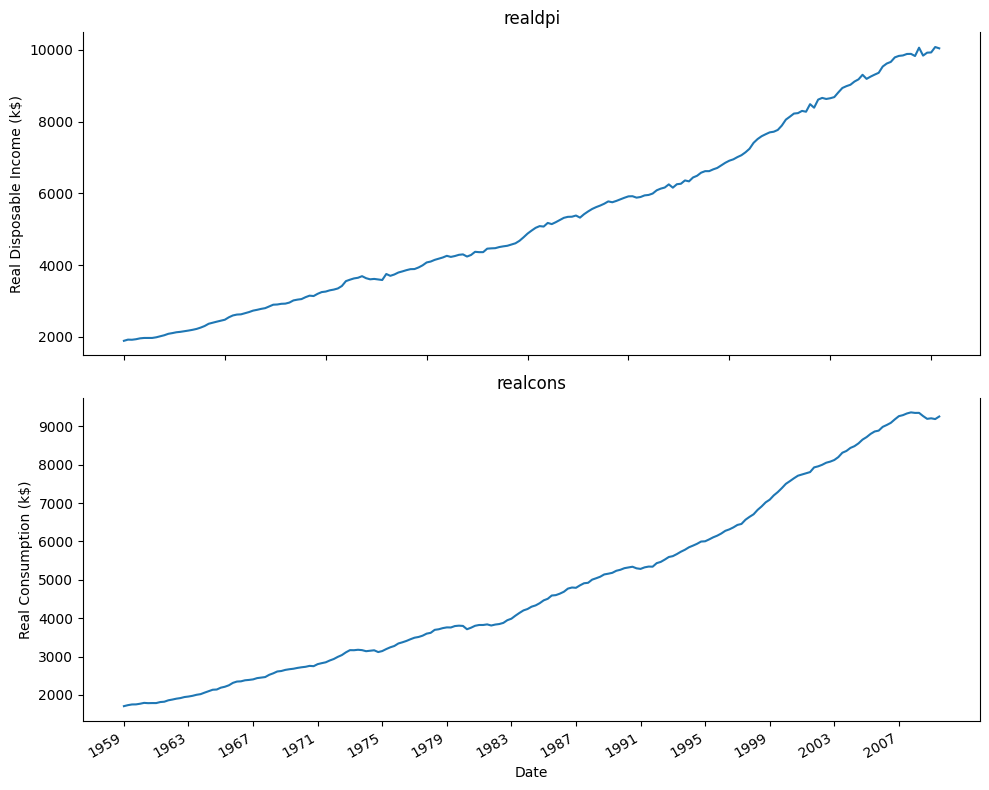

In [2]:
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, figsize = (10, 8))

ax1.plot(macro_econ_data['realdpi'])
ax1.set_xlabel('Date')
ax1.set_ylabel('Real Disposable Income (k$)')
ax1.set_title('realdpi')
ax1.spines['top'].set_alpha(0)

ax2.plot(macro_econ_data['realcons'])
ax2.set_xlabel('Date')
ax2.set_ylabel('Real Consumption (k$)')
ax2.set_title('realcons')
ax2.spines['top'].set_alpha(0)

plt.xticks(np.arange(0,208,16), np.arange(1959, 2010, 4))

fig.autofmt_xdate()
plt.tight_layout()

매우 유사한 모양 --> 직관적으로 VAR(p) 모델에 적합한 후보.  
왜?
- DPI가 높으면 CONS가 높을 가능성이 높다고 생각
- 반대로 생각하면 결국 CONS가 높으면 DPI가 높을 수 있음.
- 물론 그레인저 인과관계를 통해 검증해야 함.

데이터가 정상적인가?  
일단 도식에서는 양의 추세를 나타내기에, 정상적이지 않음. 

In [3]:
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

ad_fuller_result_1 = adfuller(macro_econ_data['realdpi'])
print('realdpi')
print(f'ADF Stats: {ad_fuller_result_1[0]}')
print(f'p-val: {ad_fuller_result_1[1]}')

print('\n--------------\n')

ad_fuller_result_2 = adfuller(macro_econ_data['realcons'])
print('realcons')
print(f'ADF Stats: {ad_fuller_result_2[0]}')
print(f'p-val: {ad_fuller_result_2[1]}')

realdpi
ADF Stats: 2.9860253519546864
p-val: 1.0

--------------

realcons
ADF Stats: 1.5499123380509636
p-val: 0.9976992503412904


귀무가설 기각할 수 없음 = 두 시계열 모두 비정상적.  
변환 (차분 후 정상성 테스트)

In [5]:
ad_fuller_result_1 = adfuller(macro_econ_data['realdpi'].diff()[1:])
print('realdpi')
print(f'ADF Stats: {ad_fuller_result_1[0]}')
print(f'p-val: {ad_fuller_result_1[1]}')

print('\n--------------\n')

ad_fuller_result_2 = adfuller(macro_econ_data['realcons'].diff()[1:])
print('realcons')
print(f'ADF Stats: {ad_fuller_result_2[0]}')
print(f'p-val: {ad_fuller_result_2[1]}')

realdpi
ADF Stats: -8.864893340673008
p-val: 1.449360615910809e-14

--------------

realcons
ADF Stats: -4.204306080845247
p-val: 0.000647928215862757


이제 귀무가설 기각하고 두 시계열은 모두 정상적임.  
VAR은 시게열이 정상적이여야 하며, 예측을 원래 규모로 돌리려면 예측을 적분해야 함.

이제 AIC가 가장 작은 모델을 선택하는 단계. 차수 p를 변경하면서 많은 VAR(p) 모델을 피팅하기 위한 optimize_VAR 함수를 작성. 

In [ ]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.varmax import VARMAX

def optimize_VAR(endog: Union[pd.Series, list]) -> pd.DataFrame:
    
    results = []
    
    for i in tqdm_notebook(range(15)):  # 0에서 14까지 차수 p를 변경
        try:
            model = VARMAX(endog, order=(i, 0)).fit(dips=False)
        except:
            continue
            
        aic = model.aic
        results.append([i, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['p', 'AIC']
    
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

이 함수를 이용해 AIC를 최소화하는 차수 p를 선택할 수 있으나, train과 test 집합을 정의해야 함.  

In [7]:
endog = macro_econ_data[['realdpi', 'realcons']]

endog_diff = macro_econ_data[['realdpi', 'realcons']].diff()[1:] #ADF 테스트에 따르면 1차 차분은 두 수열을 정상적으로 만들었으니 두 수열을 모두 차분

train = endog_diff[:162] #처음 162개 데이터 요소는 train; 약 80%
test = endog_diff[162:] # 마지막 40개는 테스트 집합. 데이터 집합의 약 20%

result_df = optimize_VAR(train) #train 집합에 저장된 차분된데이터를 사용
result_df


/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_24109/1460851074.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(15)):


  0%|          | 0/15 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: dips. After release 0.14, this will raise.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: dips. After release 0.14, this will raise.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that 

,p,AIC
0,3,3123.070079
1,5,3123.708523
2,6,3126.855593
3,4,3129.194039
4,2,3130.091668
5,7,3133.398317
6,1,3134.333343
7,8,3137.149013
8,9,3140.367183
9,10,3147.838876


p = 3이 가장 낮은 AIC 값. 그래서 VAR(3) 모델을 선택 ==> 각 시계열에서 과거의 값 3개를 사용하여 다른 시계열을 예측하는 것.  

이제 그레인저 인과관계 테스트 적용 (VAR 모델)
- realcons의 과것값이 realdpi를 예측하는 데 유용하고, realdpi의 과것값이 realcons를 예측하는 데 유용하다고 가정한다는 사실. 
- p-값이 0.05보다 크면 귀무가설을 기각할 수 없으며, 이는 변수 간에 서로 **그레인저 인과관계가 없다**는 것을 뜻하며, 모델이 유효하지 않다는 뜻.



In [8]:
print('realcons Granger-causes realdpi?\n')
print('------------------')
granger_1 = grangercausalitytests(macro_econ_data[['realdpi', 
                                                   'realcons']].diff()[1:], [3]) #두번째 변수가 그레인저 인과관계로 인해 첫 번째 변수를 유발하는지 테스트. 여기서는 realcons가 realdpi를 유발하는지 테스트. 
# 그 다음, 목록에 지연의 개수를 전달하는데 이번에는 3. 수열을 정상적으로 만들기 위해 차분을 한다는 점 유의.

print('\nrealdpi Granger-causes realcons?\n')
print('------------------')
granger_2 = grangercausalitytests(macro_econ_data[['realcons', 'realdpi']].diff()[1:], [3]) # realdpi가 realcons를 유발하는지 테스트.

realcons Granger-causes realdpi?

------------------

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=28.7191 , p=0.0000  , df=3
likelihood ratio test: chi2=26.8268 , p=0.0000  , df=3
parameter F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3

realdpi Granger-causes realcons?

------------------

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=8.7625  , p=0.0326  , df=3
likelihood ratio test: chi2=8.5751  , p=0.0355  , df=3
parameter F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3


두 변수 모두 0.05보다 작은 p-val 반환. --> 귀무가설 기가하고 realdpi가 그레인저 인과관계에 따라 realcons를 유발하고, realcons가 그레인저 인과관계에 따라 realdpi를 유발한다는 결론. VAR(3)은 유효. 
- 만일 유효하지 않다면 SARIMAX 모델을 사용해 각 시계열을 개별적으로 예측.

이제 잔차분석으로.

In [9]:
best_model = VARMAX(train, order = (3,0))
best_model_fit = best_model.fit(disp = False)

그 다음 잔차를 도식화.